# S07: Chain rule. Inverse function derivatives and logarithmic differentiation.

In [19]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from sympy import Function, diff, Symbol, latex
from sympy.plotting import plot
from IPython.display import Math, display

# Symbolic differentiation review

Let us recall how to use sympy to compute symbolic derivatives, like the ones in the exercises for this section. We will use this function for the examples below, but you are invited to try and experiment with other examples:
$$f(x) = e^{\cos 2x}$$

In [2]:
x = sy.Symbol('x')
f = sy.exp(sy.cos(2 * x))
print(f"f(x)  = {f}")


f(x)  = exp(cos(2*x))
f'(x) = -2*exp(cos(2*x))*sin(2*x)


Now we can easily get the symbolic derivative, as we have done in previous sessions:

In [16]:
df = sy.diff(f, x)
print(f"f'(x) = {df}")

f'(x) = -2*exp(cos(2*x))*sin(2*x)


And evaluate it (also symbolically) at a point:

In [17]:
x0 = sy.pi/6
df_x0 = df.subs(x, x0)
display(Math(f"f'({latex(x0)}) = {latex(df_x0)}"))


<IPython.core.display.Math object>

Symbolic differentiation allows computing explicit formulas for higher order derivatives that would otherwise be hard and error prone if computed by hand. For example, the fourth derivative of $f$ is:

In [18]:
sy.simplify(sy.diff(f, x, 4))

(256*sin(x)**8 - 1280*sin(x)**6 + 1856*sin(x)**4 - 864*sin(x)**2 + 64)*exp(cos(2*x))

# Optional: local inverses

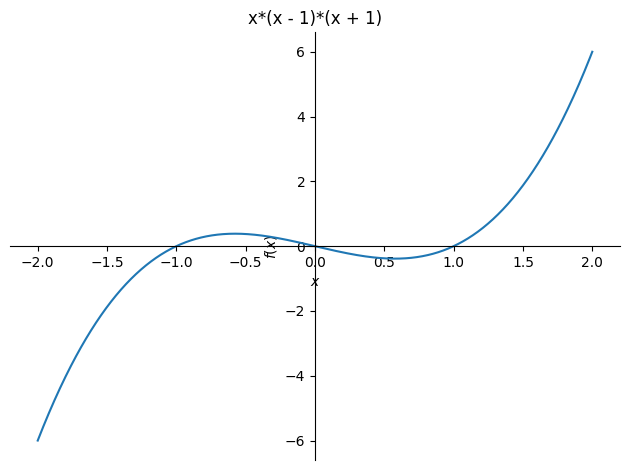

In [22]:
f = x * (x - 1) * (x + 1)
# Plot f using sympy.plot
plot(f, (x, -2, 2), title=str(f))

In [23]:
y = sy.Symbol('y')

# Solve y = f for x
solutions = sy.solve(sy.Eq(y, f), x)

# Display the solutions
print(f"Solutions for x in terms of y: {solutions}")

# Optionally, display in a more readable LaTeX format
for i, sol in enumerate(solutions):
    display(Math(f"x_{i+1} = {latex(sol)}"))

Solutions for x in terms of y: [-(-1/2 - sqrt(3)*I/2)*(-27*y/2 + sqrt(729*y**2 - 108)/2)**(1/3)/3 - 1/((-1/2 - sqrt(3)*I/2)*(-27*y/2 + sqrt(729*y**2 - 108)/2)**(1/3)), -(-1/2 + sqrt(3)*I/2)*(-27*y/2 + sqrt(729*y**2 - 108)/2)**(1/3)/3 - 1/((-1/2 + sqrt(3)*I/2)*(-27*y/2 + sqrt(729*y**2 - 108)/2)**(1/3)), -(-27*y/2 + sqrt(729*y**2 - 108)/2)**(1/3)/3 - 1/(-27*y/2 + sqrt(729*y**2 - 108)/2)**(1/3)]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [24]:
# Calculate the first derivative of f(x)
f_prime = sy.diff(f, x)

# Find the critical points by solving f'(x) = 0
critical_points = sy.solve(sy.Eq(f_prime, 0), x)

# Filter for real critical points within the plotting range (-2 to 2)
real_critical_points = [point.evalf() for point in critical_points if point.is_real and -2 <= point.evalf() <= 2]
real_critical_points = sorted(list(set(real_critical_points))) # Remove duplicates and sort

print(f"Critical points of f(x) within [-2, 2]: {real_critical_points}")

Critical points of f(x) within [-2, 2]: [-0.577350269189626, 0.577350269189626]


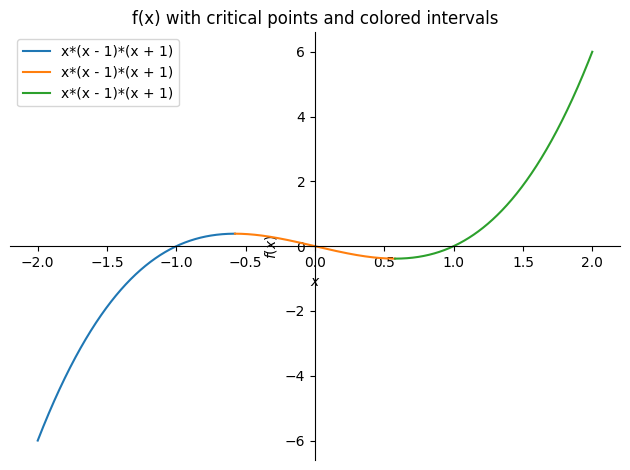

In [25]:
import matplotlib.colors as mcolors

# Define the overall plotting range
x_min_plot, x_max_plot = -2, 2

# Combine plot boundaries with critical points to define segments
segment_boundaries = sorted(list(set([x_min_plot] + real_critical_points + [x_max_plot])))

# Generate a color map
colors = list(mcolors.TABLEAU_COLORS.values()) # Using a standard color palette

# Create the plot
p = sy.plot(show=False, legend=True, title=f'f(x) with critical points and colored intervals')

# Iterate through segments and plot f(x) with different colors
for i in range(len(segment_boundaries) - 1):
    start_x = segment_boundaries[i]
    end_x = segment_boundaries[i+1]

    # Ensure the interval is not empty and covers a positive length
    if end_x > start_x:
        # Sympy plot expects (expression, (symbol, start, end)) for each series
        p.append(sy.plot(f, (x, start_x, end_x), show=False, line_color=colors[i % len(colors)])[0])

# Display the plot
p.show()